In [1]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# # Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# # Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

# import kagglehub
# # kagglehub.dataset_download('<owner>/<dataset-slug>')

# 1. IMPORT LIBRARY

In [2]:
import os
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score, precision_score, recall_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset, WeightedRandomSampler
from torchvision import transforms
from torch.cuda.amp import autocast, GradScaler
from tqdm import tqdm
from IPython.display import FileLink

try:
    import timm
except ImportError:
    !pip install -q timm
    import timm

# 2. SET UP KONFIGURASI

In [3]:
# SEED = 42
# IMG_SIZE = 224
# BATCH_SIZE = 64
# NUM_EPOCHS = 35
# PATIENCE = 10
# NUM_CLASSES = 3
# DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# OUTPUT_DIR = '/kaggle/working'
# os.makedirs(OUTPUT_DIR, exist_ok=True)

# PSEUDO_LABEL_THRESHOLD = 0.95

# def set_seed(seed=42):
#     random.seed(seed)
#     np.random.seed(seed)
#     torch.manual_seed(seed)
#     torch.cuda.manual_seed_all(seed)

# set_seed(SEED)
# print(f'Device: {DEVICE}')

In [4]:
SEED = 42
IMG_SIZE = 224
BATCH_SIZE = 16
GRAD_ACCUM_STEPS = 2
NUM_EPOCHS = 35
PATIENCE = 10
NUM_CLASSES = 3
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
OUTPUT_DIR = '/kaggle/working'  # Ganti dengan folder output Anda

MODEL_NAME = 'convnext_large_99'

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
set_seed(SEED)

print(f'Device: {DEVICE}')
print(f'Model: ConvNeXt-Large')
print(f'Batch Size: {BATCH_SIZE}')
print(f'Epochs: {NUM_EPOCHS}')

Device: cuda
Model: ConvNeXt-Large
Batch Size: 16
Epochs: 35


# 3. LOAD DATASET & DATA CLEANING

In [5]:
BASE_DIR = '/kaggle/input/datasets/affrizawildanfauzan/dataset-penyisihan-bdc26/Penyisihan'
TRAIN_DIR = os.path.join(BASE_DIR, 'train')
TEST_DIR = os.path.join(BASE_DIR, 'test')

print("="*50)
print("DATASET PATH")
print("="*50)
print(f"TRAIN_DIR: {TRAIN_DIR}")
print(f"TEST_DIR: {TEST_DIR}")

DATASET PATH
TRAIN_DIR: /kaggle/input/datasets/affrizawildanfauzan/dataset-penyisihan-bdc26/Penyisihan/train
TEST_DIR: /kaggle/input/datasets/affrizawildanfauzan/dataset-penyisihan-bdc26/Penyisihan/test


In [6]:
# DATA CLEANING 

def validate_dataset(directory):
    print("\nValidasi Dataset")
    total_images = 0
    corrupted = 0
    
    for class_name in os.listdir(directory):
        class_path = os.path.join(directory, class_name)
        if os.path.isdir(class_path):
            images = [f for f in os.listdir(class_path) 
                     if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            total_images += len(images)
            
            for img_file in images:
                img_path = os.path.join(class_path, img_file)
                try:
                    with Image.open(img_path) as img:
                        img.verify()
                except:
                    corrupted += 1
                    print(f"    Corrupted: {img_path}")
    
    print(f"  Total images: {total_images}")
    print(f"  Corrupted: {corrupted}")
    return total_images, corrupted

# Jalankan validasi
validate_dataset(TRAIN_DIR)


Validasi Dataset
  Total images: 26527
  Corrupted: 0


(26527, 0)

# 4. EDA

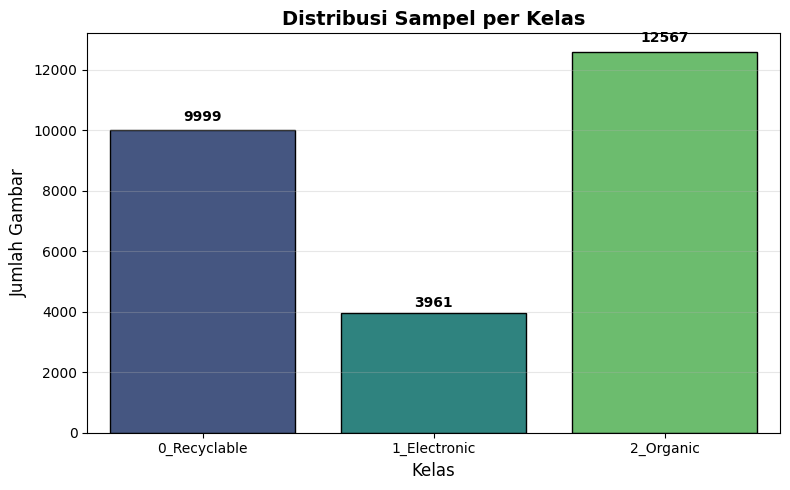

In [7]:
# VISUALISASI DISTRIBUSI SETIAP KELAS
class_names = ['0_Recyclable', '1_Electronic', '2_Organic']
train_counts = {}

for cls in class_names:
    cls_path = os.path.join(TRAIN_DIR, cls)
    if os.path.exists(cls_path):
        train_counts[cls] = len(os.listdir(cls_path))
    else:
        train_counts[cls] = 0

# DataFrame distribusi
df_train = pd.DataFrame({
    'Kelas': class_names,
    'Jumlah': [train_counts[cls] for cls in class_names]
})

# Visualisasi distribusi dengan nilai di atas bar
plt.figure(figsize=(8,5))
ax = sns.barplot(data=df_train, x='Kelas', y='Jumlah', palette='viridis', edgecolor='black')
plt.title('Distribusi Sampel per Kelas', fontsize=14, fontweight='bold')
plt.ylabel('Jumlah Gambar', fontsize=12)
plt.xlabel('Kelas', fontsize=12)
plt.grid(axis='y', alpha=0.3)

# Tambahkan nilai di atas bar
for i, row in df_train.iterrows():
    ax.text(i, row['Jumlah'] + (row['Jumlah'] * 0.02), 
            f"{row['Jumlah']}", 
            ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

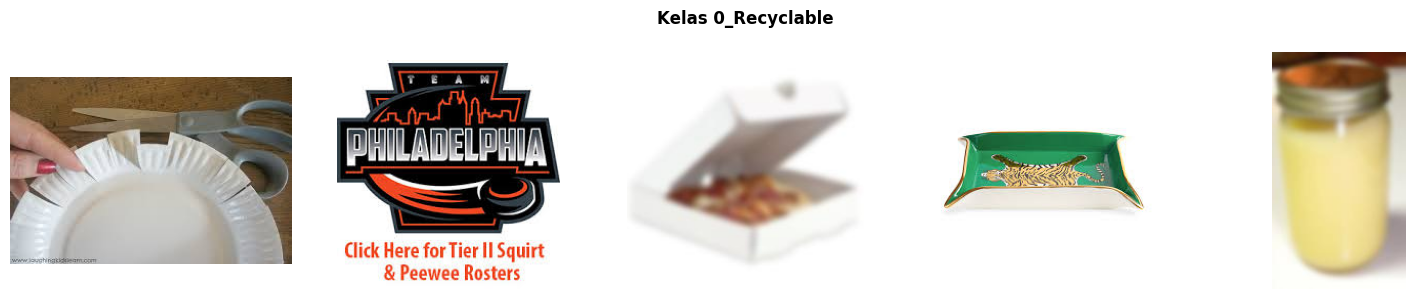

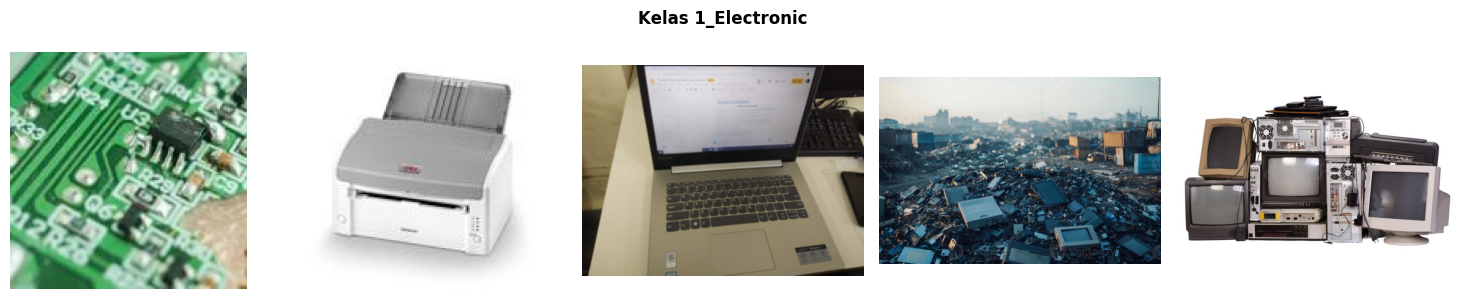

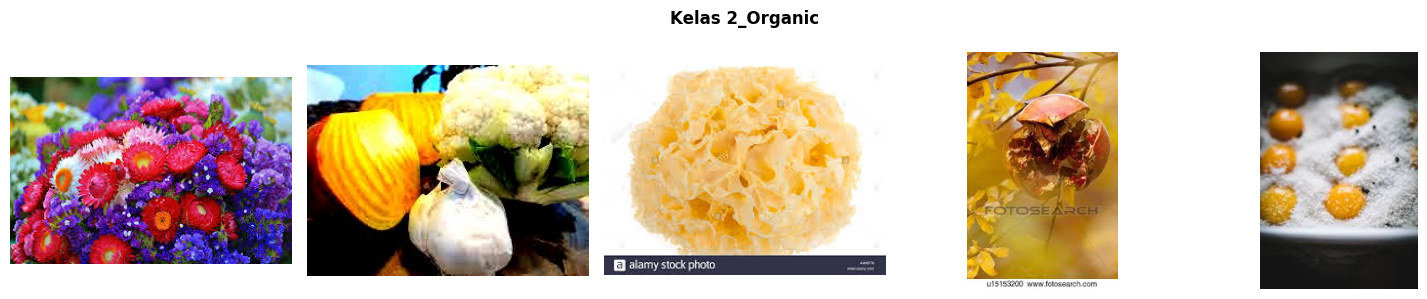

In [8]:
# VSIUALISASI SAMPEL PER KELAS
def visualization_sample(class_name, n_samples=5):
    class_dir = os.path.join(TRAIN_DIR, class_name)
    sample_files = os.listdir(class_dir)[:n_samples]
    
    # Hitung total gambar di kelas
    total = len(os.listdir(class_dir))
    
    fig, axes = plt.subplots(1, n_samples, figsize=(15, 3))
    
    for j, img_file in enumerate(sample_files):
        img_path = os.path.join(class_dir, img_file)
        img = Image.open(img_path)
        
        # Informasi ukuran gambar
        width, height = img.size
        
        axes[j].imshow(img)
        axes[j].axis('off')
    
    plt.suptitle(f'Kelas {class_name}', fontweight='bold')
    plt.tight_layout()
    plt.show()

# Eksekusi
for class_name in os.listdir(TRAIN_DIR):
    visualization_sample(class_name)

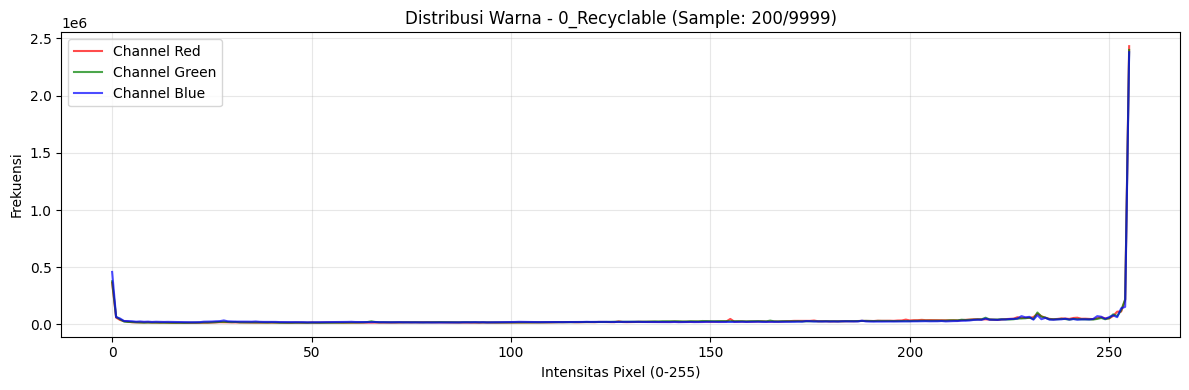

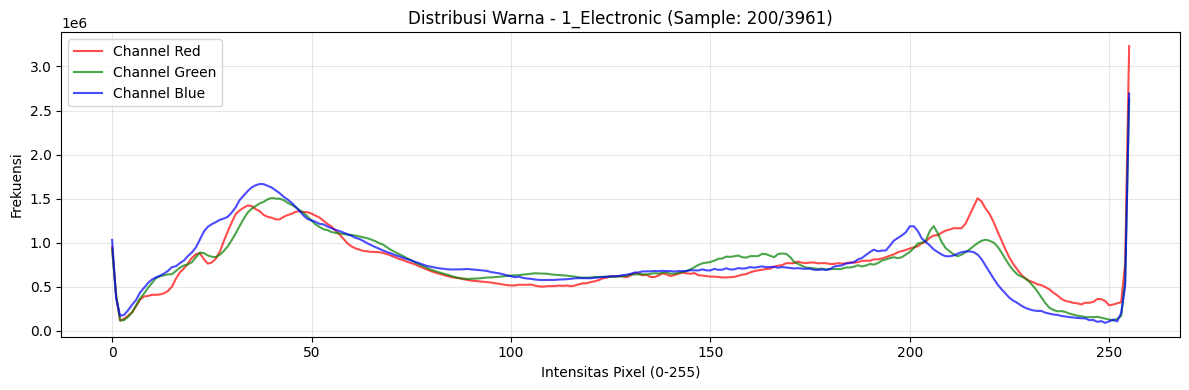

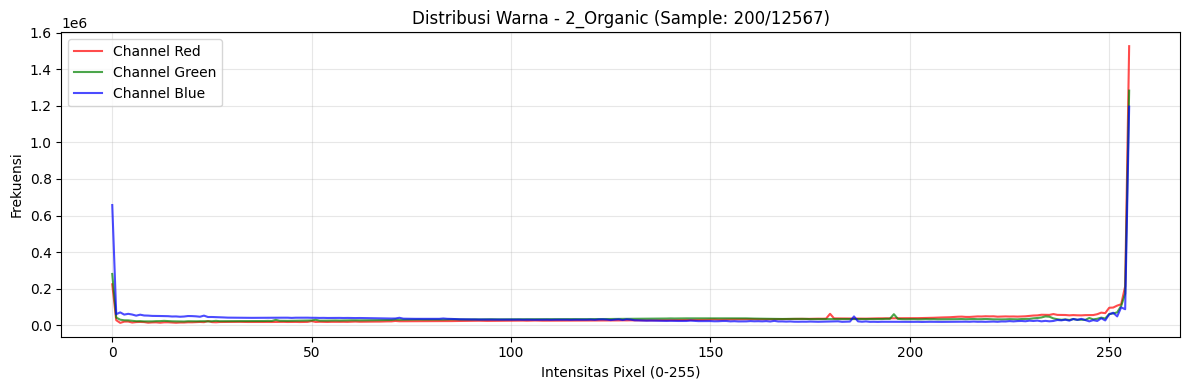

In [9]:
# ANALISIS WARNA
def plot_color_histograms(class_name, num_samples=200):
    class_dir = os.path.join(TRAIN_DIR, class_name)
    files = os.listdir(class_dir)[:num_samples]
    
    plt.figure(figsize=(12, 4))
    
    # Warna untuk RGB
    colors = ('red', 'green', 'blue')
    channel_ids = (0, 1, 2)
    
    for channel_id, color in zip(channel_ids, colors):
        histogram = np.zeros(256)
        for img_file in files:
            img_path = os.path.join(class_dir, img_file)
            img = Image.open(img_path)
            img_array = np.array(img)
            
            # Cek dimensi gambar
            if len(img_array.shape) == 3:  # RGB
                hist, _ = np.histogram(img_array[:, :, channel_id].ravel(), 
                                      bins=256, range=(0, 256))
                histogram += hist
            else:  # Grayscale
                # Jika grayscale, semua channel sama
                hist, _ = np.histogram(img_array.ravel(), 
                                      bins=256, range=(0, 256))
                histogram += hist
        
        plt.plot(histogram, color=color, alpha=0.7, 
                label=f'Channel {color.capitalize()}')
    
    # Total gambar yang dianalisis
    total_analyzed = len(files)
    total_images = len(os.listdir(class_dir))
    
    plt.title(f'Distribusi Warna - {class_name} (Sample: {total_analyzed}/{total_images})')
    plt.xlabel('Intensitas Pixel (0-255)')
    plt.ylabel('Frekuensi')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# Eksekusi semua kelas
for class_name in os.listdir(TRAIN_DIR):
    plot_color_histograms(class_name, num_samples=200)

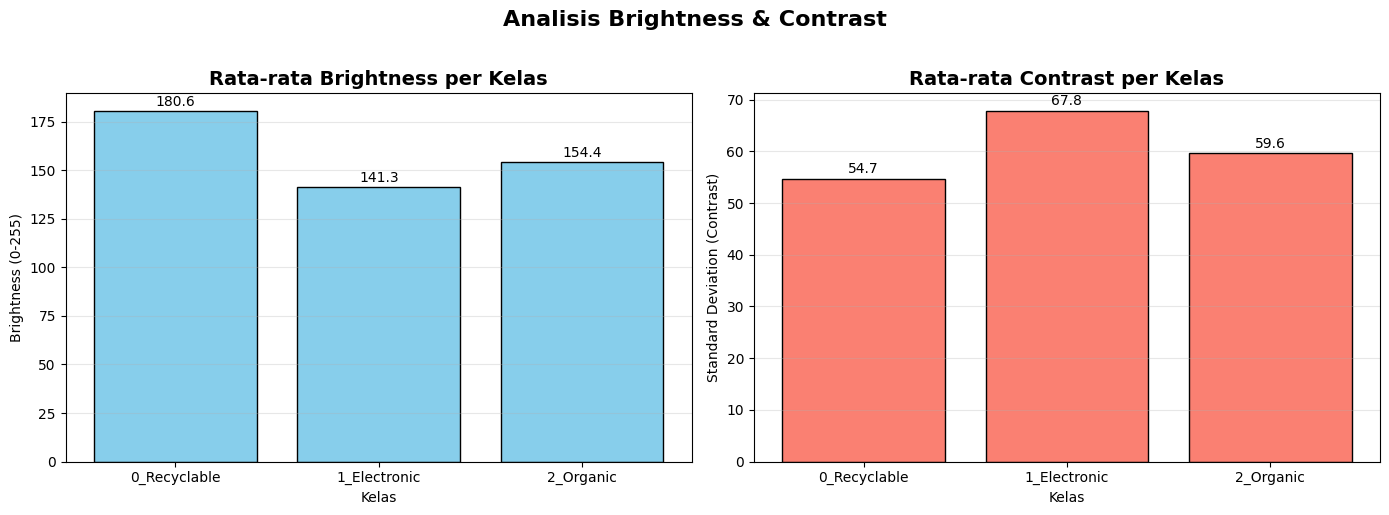

In [10]:
# ANALISIS CONTRAST & BRIGHTNESS
def compute_image_stats(class_name, num_samples=200):
    class_dir = os.path.join(TRAIN_DIR, class_name)
    files = os.listdir(class_dir)[:num_samples]
    
    brightness = []
    contrast = []
    
    for img_file in files:
        img_path = os.path.join(class_dir, img_file)
        img = Image.open(img_path).convert('L')  # Grayscale
        img_array = np.array(img)
        brightness.append(np.mean(img_array))
        contrast.append(np.std(img_array))
    
    return np.mean(brightness), np.mean(contrast), len(files)

# Hitung statistik
stats = {}
for class_name in os.listdir(TRAIN_DIR):
    brightness, contrast, sample_used = compute_image_stats(class_name)
    stats[class_name] = {
        'brightness': brightness, 
        'contrast': contrast,
        'samples': sample_used
    }

# Buat DataFrame
df_stats = pd.DataFrame(stats).T

# Visualisasi dengan subplot yang lebih rapi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Brightness
bars1 = axes[0].bar(df_stats.index, df_stats['brightness'], color='skyblue', edgecolor='black')
axes[0].set_title('Rata-rata Brightness per Kelas', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Brightness (0-255)')
axes[0].set_xlabel('Kelas')
axes[0].grid(axis='y', alpha=0.3)
# Tambahkan nilai di atas bar
for bar, val in zip(bars1, df_stats['brightness']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                f'{val:.1f}', ha='center', va='bottom', fontsize=10)

# Contrast
bars2 = axes[1].bar(df_stats.index, df_stats['contrast'], color='salmon', edgecolor='black')
axes[1].set_title('Rata-rata Contrast per Kelas', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Standard Deviation (Contrast)')
axes[1].set_xlabel('Kelas')
axes[1].grid(axis='y', alpha=0.3)
# Tambahkan nilai di atas bar
for bar, val in zip(bars2, df_stats['contrast']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                f'{val:.1f}', ha='center', va='bottom', fontsize=10)

plt.suptitle('Analisis Brightness & Contrast', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

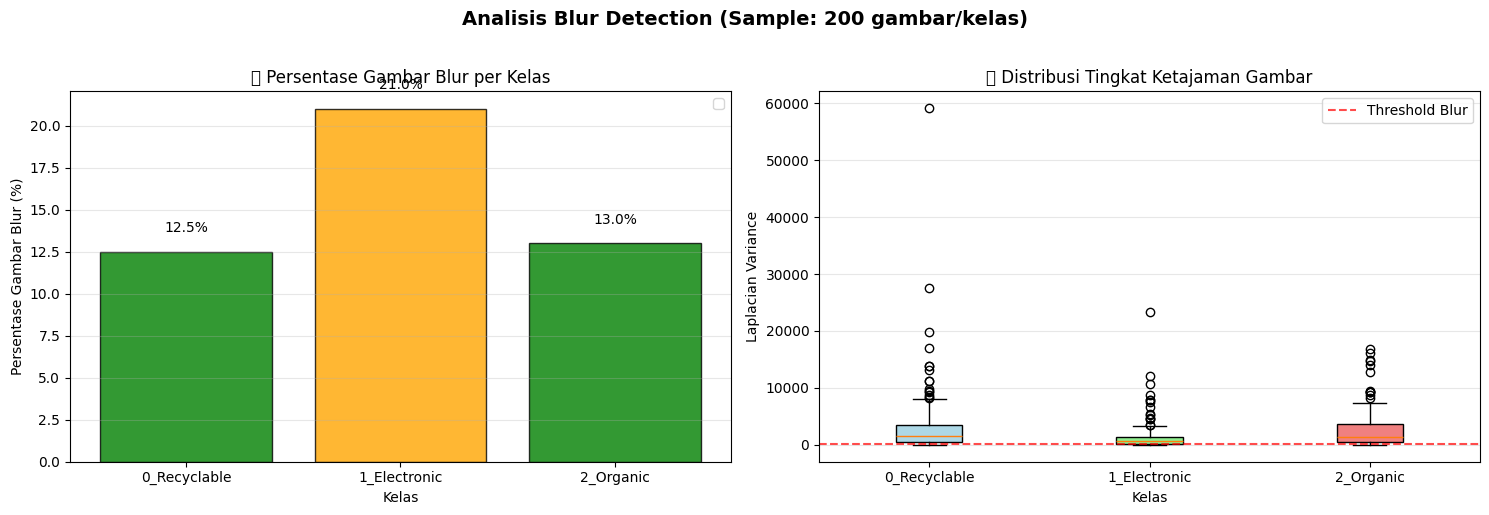


tatistik Blur per Kelas:
              Mean Variance  Std Variance  Min Variance  Max Variance  Blur %
0_Recyclable        3043.04       5433.54          2.55      59161.90    12.5
1_Electronic        1342.24       2405.82          2.49      23364.77    21.0
2_Organic           2562.49       3059.89          6.44      16819.34    13.0


In [11]:
# BLUR DETECTION
from scipy import ndimage

def detect_blur_laplacian(image_path):
    img = Image.open(image_path).convert('L')
    img_array = np.array(img, dtype=np.float64)
    laplacian = ndimage.laplace(img_array)
    return laplacian.var()

def analyze_blur_per_class(class_name, num_samples=200, threshold=100):
    class_dir = os.path.join(TRAIN_DIR, class_name)
    files = os.listdir(class_dir)[:num_samples]
    
    laplacian_vars = []
    for img_file in files:
        img_path = os.path.join(class_dir, img_file)
        variance = detect_blur_laplacian(img_path)
        laplacian_vars.append(variance)
    
    blur_count = sum(1 for v in laplacian_vars if v < threshold)
    
    return {
        'mean': np.mean(laplacian_vars),
        'std': np.std(laplacian_vars),
        'min': np.min(laplacian_vars),
        'max': np.max(laplacian_vars),
        'blur_percentage': (blur_count / len(laplacian_vars)) * 100,
        'variances': laplacian_vars
    }

# Analisis semua kelas
classes = sorted(os.listdir(TRAIN_DIR))
blur_stats = {cls: analyze_blur_per_class(cls) for cls in classes}

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Persentase Blur
blur_pcts = [blur_stats[c]['blur_percentage'] for c in classes]
colors = ['red' if p > 30 else 'orange' if p > 15 else 'green' for p in blur_pcts]
bars = axes[0].bar(classes, blur_pcts, color=colors, edgecolor='black', alpha=0.8)

for bar, pct in zip(bars, blur_pcts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                f'{pct:.1f}%', ha='center', va='bottom', fontsize=10)
axes[0].set_xlabel('Kelas')
axes[0].set_ylabel('Persentase Gambar Blur (%)')
axes[0].set_title('🔍 Persentase Gambar Blur per Kelas')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# 2. Boxplot distribusi variance
data_to_plot = [blur_stats[c]['variances'] for c in classes]
bp = axes[1].boxplot(data_to_plot, labels=classes, patch_artist=True)

for patch, color in zip(bp['boxes'], ['lightblue', 'lightgreen', 'lightcoral']):
    patch.set_facecolor(color)

axes[1].axhline(y=100, color='red', linestyle='--', alpha=0.7, label='Threshold Blur')
axes[1].set_xlabel('Kelas')
axes[1].set_ylabel('Laplacian Variance')
axes[1].set_title('📊 Distribusi Tingkat Ketajaman Gambar')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle(f'Analisis Blur Detection (Sample: {len(blur_stats[classes[0]]["variances"])} gambar/kelas)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Tampilkan statistik detail
print("\ntatistik Blur per Kelas:")
df_blur = pd.DataFrame({
    c: {
        'Mean Variance': blur_stats[c]['mean'],
        'Std Variance': blur_stats[c]['std'],
        'Min Variance': blur_stats[c]['min'],
        'Max Variance': blur_stats[c]['max'],
        'Blur %': blur_stats[c]['blur_percentage']
    }
    for c in classes
}).T.round(2)
print(df_blur)

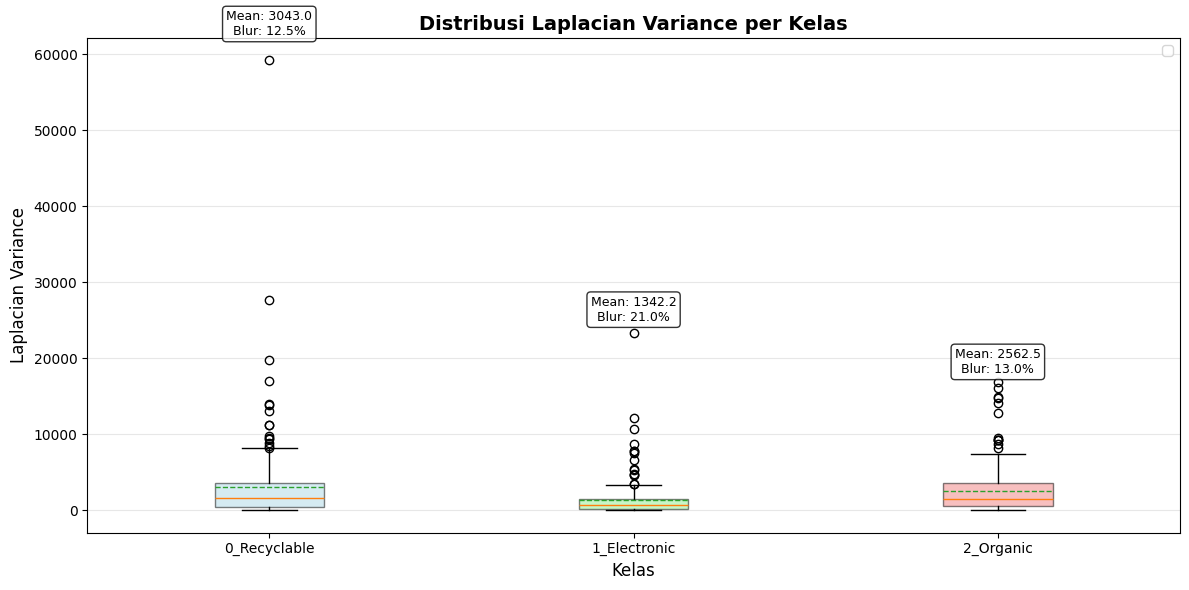

In [12]:
# LAPLACIAN VARIANCE
fig, ax = plt.subplots(figsize=(12, 6))

# Ambil data langsung dari blur_stats
classes = list(blur_stats.keys())
all_variances = [blur_stats[c]['variances'] for c in classes]

# Boxplot
bp = ax.boxplot(all_variances, labels=classes, patch_artist=True, 
                showmeans=True, meanline=True)

# Warna boxplot
colors = ['lightblue', 'lightgreen', 'lightcoral']
for box, color in zip(bp['boxes'], colors):
    box.set_facecolor(color)
    box.set_alpha(0.5)

# Tambahkan label statistik di atas boxplot
for i, class_name in enumerate(classes):
    stats = blur_stats[class_name]
    ax.text(i+1, stats['max'] * 1.05, 
            f'Mean: {stats["mean"]:.1f}\nBlur: {stats["blur_percentage"]:.1f}%',
            ha='center', va='bottom', fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))

ax.set_xlabel('Kelas', fontsize=12)
ax.set_ylabel('Laplacian Variance', fontsize=12)
ax.set_title('Distribusi Laplacian Variance per Kelas', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Statistik Piksel per Kelas:


,mean,std,skew,kurtosis,samples
class,,,,,
0_Recyclable,169.550995,81.138000,-0.536,-1.071,50
1_Electronic,123.261002,60.858002,-0.077,-0.962,50
2_Organic,148.391006,73.407997,-0.173,-1.017,50


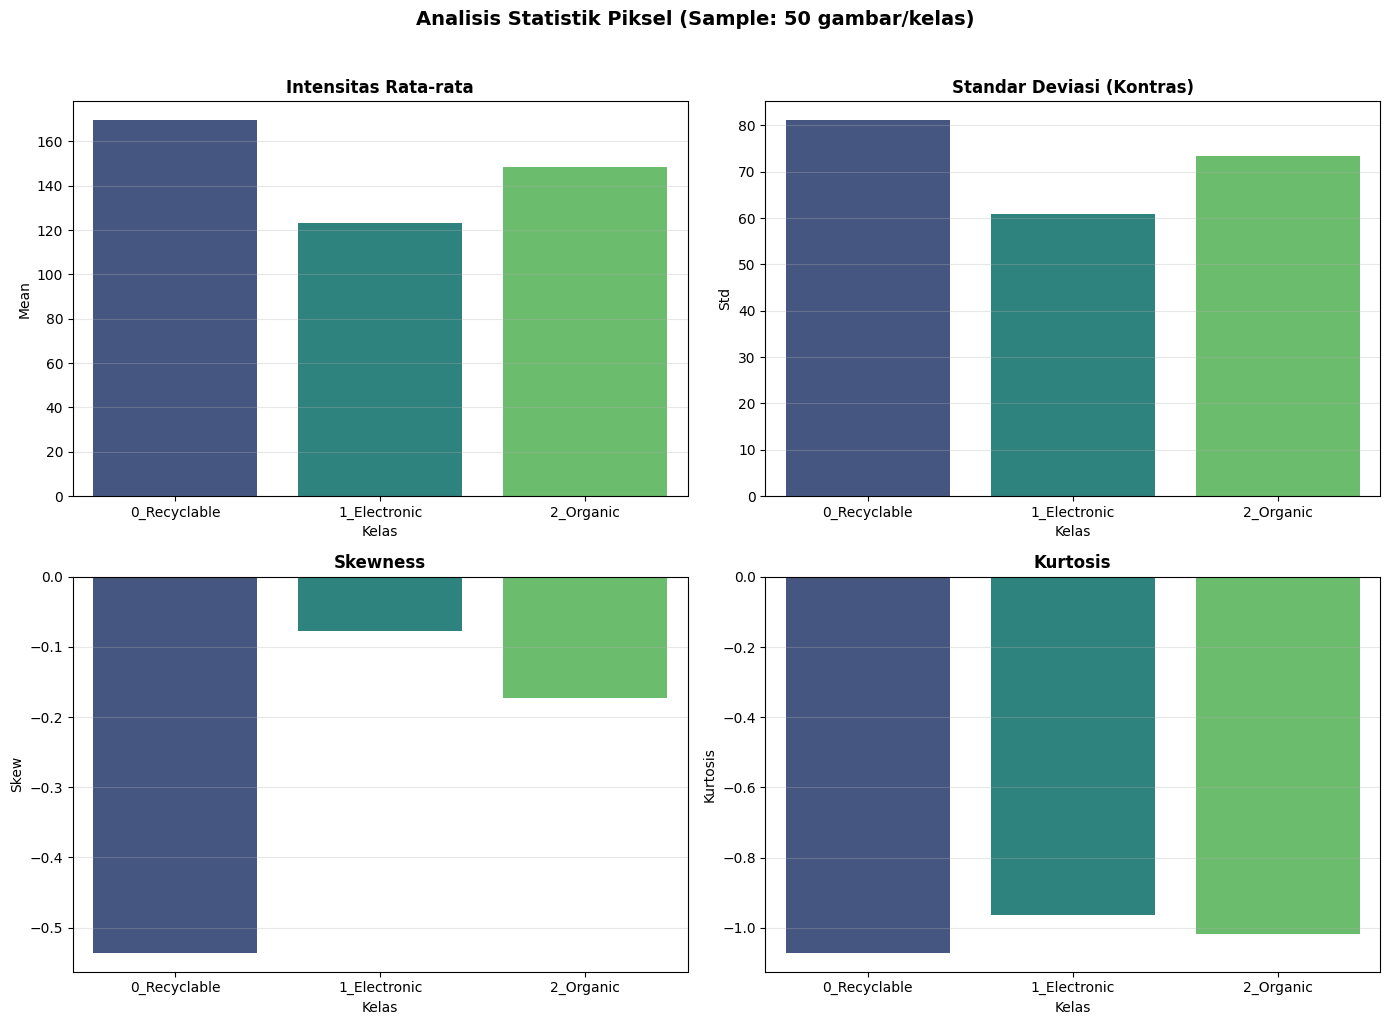

In [13]:
# PIXEL STATISTICS
from scipy.stats import skew, kurtosis

def compute_pixel_stats(samples_per_class=50):
    """Menghitung statistik piksel untuk setiap kelas."""
    records = []
    
    for class_name in os.listdir(TRAIN_DIR):
        class_dir = os.path.join(TRAIN_DIR, class_name)
        files = os.listdir(class_dir)[:samples_per_class]
        
        all_pixels = []
        for img_file in files:
            img_path = os.path.join(class_dir, img_file)
            img = np.array(Image.open(img_path).convert('L')).flatten()
            all_pixels.extend(img.tolist())
        
        arr = np.array(all_pixels, dtype=np.float32)
        records.append({
            "class": class_name,
            "mean": round(arr.mean(), 3),
            "std": round(arr.std(), 3),
            "skew": round(float(skew(arr)), 3),
            "kurtosis": round(float(kurtosis(arr)), 3),
            "samples": len(files)
        })
    
    return pd.DataFrame(records)

# Eksekusi
pixel_stats = compute_pixel_stats()
print("Statistik Piksel per Kelas:")
display(pixel_stats.set_index("class"))

# Visualisasi dengan viridis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics = ["mean", "std", "skew", "kurtosis"]
titles = ["Intensitas Rata-rata", "Standar Deviasi (Kontras)", "Skewness", "Kurtosis"]

for ax, metric, title in zip(axes.flat, metrics, titles):
    sns.barplot(data=pixel_stats, x="class", y=metric, ax=ax, palette="viridis")
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_xlabel('Kelas', fontsize=10)
    ax.set_ylabel(metric.capitalize(), fontsize=10)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle(f'Analisis Statistik Piksel (Sample: {pixel_stats["samples"].iloc[0]} gambar/kelas)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

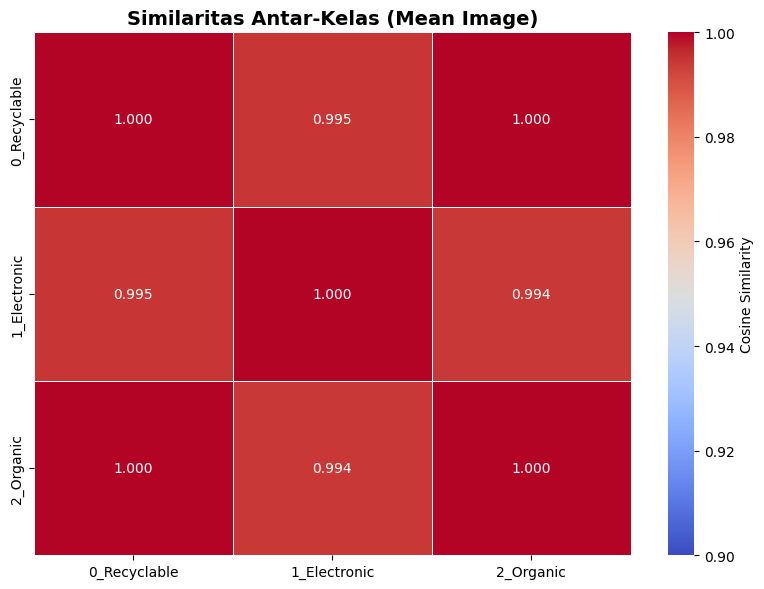

In [14]:
# PARIWISE CLASS SIMILARITY
from sklearn.metrics.pairwise import cosine_similarity

def compute_mean_images(target_size=(64, 64)):
    """Menghitung rata-rata citra per kelas."""
    mean_vecs = {}
    
    for class_name in os.listdir(TRAIN_DIR):
        class_dir = os.path.join(TRAIN_DIR, class_name)
        files = os.listdir(class_dir)
        
        accum = np.zeros(target_size[0] * target_size[1], dtype=np.float64)
        count = 0
        
        for img_file in files:
            img_path = os.path.join(class_dir, img_file)
            img = Image.open(img_path).convert('L').resize(target_size)
            accum += np.array(img, dtype=np.float64).flatten()
            count += 1
        
        if count > 0:
            mean_vecs[class_name] = accum / count
    
    return mean_vecs

# Eksekusi
mean_vecs = compute_mean_images()
classes_list = sorted(mean_vecs.keys())

# Hitung similarity
mat = np.array([mean_vecs[c] for c in classes_list])
sim = cosine_similarity(mat)

# Visualisasi
fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    sim, 
    annot=True, 
    fmt=".3f", 
    cmap="coolwarm",
    xticklabels=classes_list, 
    yticklabels=classes_list,
    vmin=0.9, 
    vmax=1.0, 
    linewidths=0.5, 
    ax=ax,
    cbar_kws={"label": "Cosine Similarity"}
)

ax.set_title("Similaritas Antar-Kelas (Mean Image)", fontweight='bold', fontsize=14)

plt.tight_layout()
plt.show()

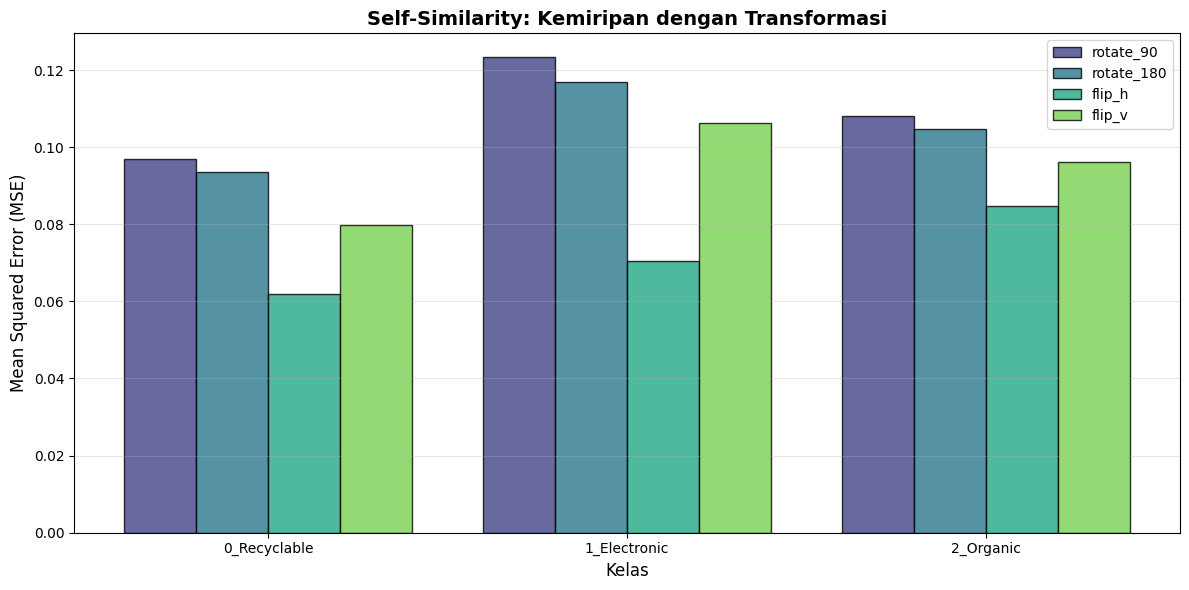

In [15]:
# SELF SIMILARITY
def compute_self_similarity(class_name, num_samples=50):
    class_dir = os.path.join(TRAIN_DIR, class_name)
    files = os.listdir(class_dir)[:num_samples]
    
    similarities = {'rotate_90': [], 'rotate_180': [], 'flip_h': [], 'flip_v': []}
    
    for img_file in files:
        img_path = os.path.join(class_dir, img_file)
        img = np.array(Image.open(img_path).resize((64, 64))).astype(np.float32) / 255.0
        
        # Buat transformasi
        transforms = {
            'rotate_90': np.rot90(img, k=1),
            'rotate_180': np.rot90(img, k=2),
            'flip_h': np.fliplr(img),
            'flip_v': np.flipud(img)
        }
        
        # Hitung similarity (MSE)
        for name, transformed in transforms.items():
            similarities[name].append(np.mean((img - transformed)**2))
    
    return {k: np.mean(v) for k, v in similarities.items()}

# Compute untuk semua kelas
classes = sorted(os.listdir(TRAIN_DIR))
self_sim_data = {class_name: compute_self_similarity(class_name) for class_name in classes}

# Visualisasi dengan viridis
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(classes))
width = 0.2

transf = ['rotate_90', 'rotate_180', 'flip_h', 'flip_v']
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(transf)))

for i, (transform, color) in enumerate(zip(transf, colors)):
    values = [self_sim_data[c][transform] for c in classes]
    ax.bar(x + i*width, values, width, label=transform, color=color, alpha=0.8, edgecolor='black')

ax.set_xlabel('Kelas', fontsize=12)
ax.set_ylabel('Mean Squared Error (MSE)', fontsize=12)
ax.set_title('Self-Similarity: Kemiripan dengan Transformasi', fontsize=14, fontweight='bold')
ax.set_xticks(x + width*1.5)
ax.set_xticklabels(classes)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

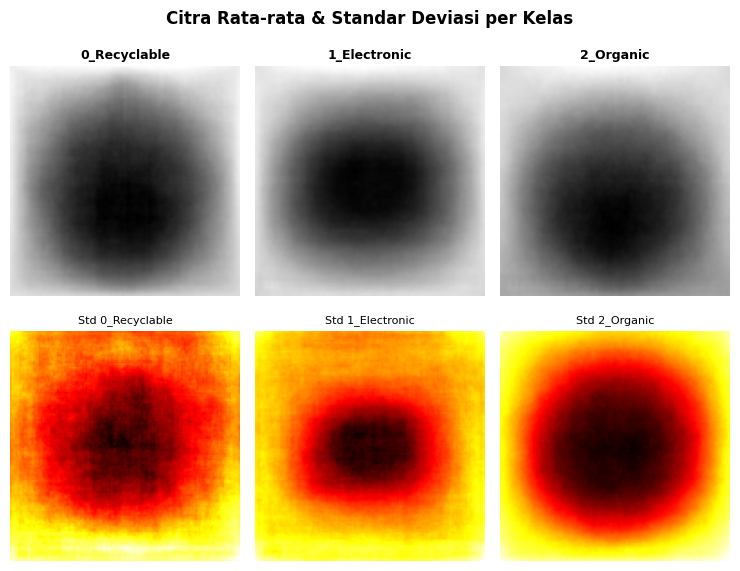

In [16]:
# CITRA RATA-RATA DAN STANDAR DEVIASI PER KELAS
RESIZE_TARGET = (128, 128)

# Dapatkan daftar kelas dari folder
classes = sorted(os.listdir(TRAIN_DIR))
NUM_CLASSES = len(classes)

fig, axes = plt.subplots(2, NUM_CLASSES, figsize=(NUM_CLASSES * 2.5, 6))

for idx, class_name in enumerate(classes):
    class_dir = os.path.join(TRAIN_DIR, class_name)
    files = os.listdir(class_dir)
    
    stack = []
    for img_file in files:
        img_path = os.path.join(class_dir, img_file)
        img = np.array(
            Image.open(img_path).convert('L').resize(RESIZE_TARGET),
            dtype=np.float32
        )
        stack.append(img)
    
    stack = np.array(stack)
    mean_img = stack.mean(axis=0)
    std_img = stack.std(axis=0)
    
    # Plot mean image
    axes[0, idx].imshow(mean_img, cmap='gray')
    axes[0, idx].set_title(f'{class_name}', fontsize=9, fontweight='bold')
    axes[0, idx].axis('off')
    
    # Plot std image
    axes[1, idx].imshow(std_img, cmap='hot')
    axes[1, idx].set_title(f'Std {class_name}', fontsize=8)
    axes[1, idx].axis('off')

axes[0, 0].set_ylabel('Mean', fontweight='bold')
axes[1, 0].set_ylabel('Std', fontweight='bold')
plt.suptitle('Citra Rata-rata & Standar Deviasi per Kelas', fontweight='bold')
plt.tight_layout()
plt.show()

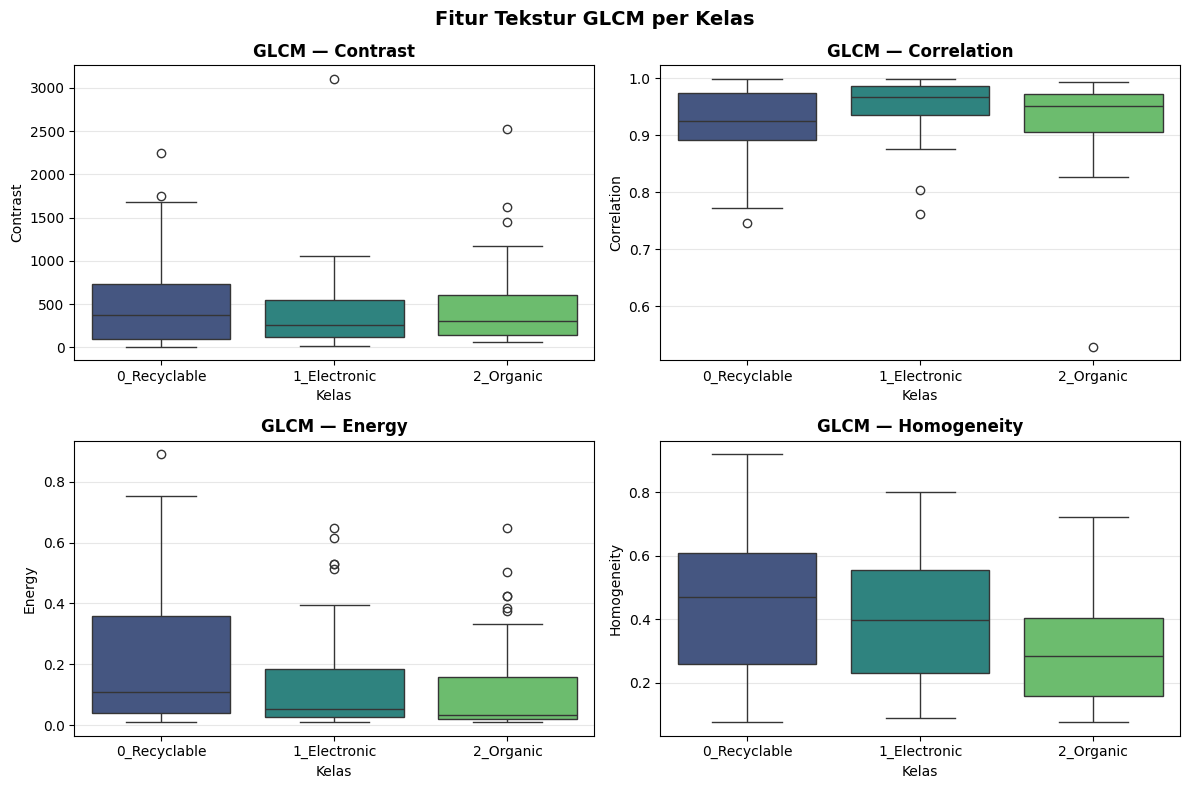

In [17]:
# GLCM FEATURE TEXTURES
from skimage.feature import graycomatrix, graycoprops

RESIZE_TARGET = (128, 128)
glcm_records = []
sample_per_class = 50

for class_name in os.listdir(TRAIN_DIR):
    class_dir = os.path.join(TRAIN_DIR, class_name)
    files = os.listdir(class_dir)[:sample_per_class]
    
    for img_file in files:
        img_path = os.path.join(class_dir, img_file)
        img = np.array(Image.open(img_path).convert('L').resize(RESIZE_TARGET))
        
        # Hitung GLCM
        glcm = graycomatrix(img, distances=[1], angles=[0],
                           levels=256, symmetric=True, normed=True)
        
        glcm_records.append({
            "class": class_name,
            "contrast": graycoprops(glcm, "contrast")[0, 0],
            "correlation": graycoprops(glcm, "correlation")[0, 0],
            "energy": graycoprops(glcm, "energy")[0, 0],
            "homogeneity": graycoprops(glcm, "homogeneity")[0, 0],
        })

glcm_df = pd.DataFrame(glcm_records)

# Visualisasi
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
props = ["contrast", "correlation", "energy", "homogeneity"]
titles = ["Contrast", "Correlation", "Energy", "Homogeneity"]

for ax, prop, title in zip(axes.flatten(), props, titles):
    sns.boxplot(data=glcm_df, x="class", y=prop, palette="viridis", ax=ax)
    ax.set_title(f"GLCM — {title}", fontweight='bold')
    ax.set_xlabel('Kelas')
    ax.set_ylabel(title)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Fitur Tekstur GLCM per Kelas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

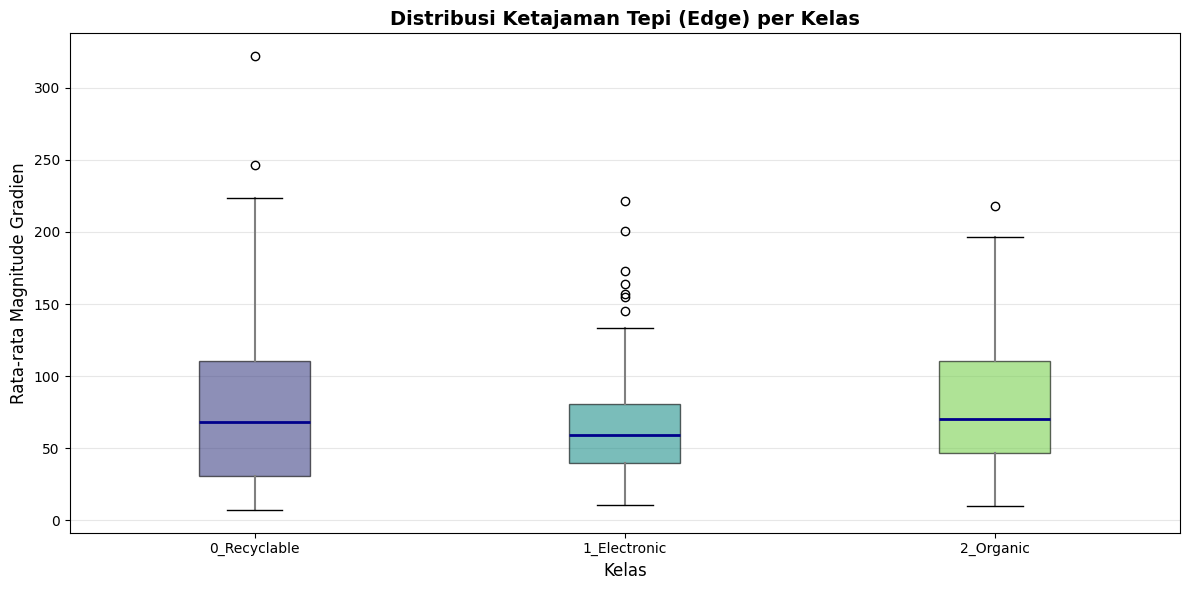

In [18]:
# EDGE DENSITY/GRADIENT
from scipy import ndimage

def analyze_gradient_magnitude(class_name, num_samples=100):
    class_dir = os.path.join(TRAIN_DIR, class_name)
    files = os.listdir(class_dir)[:num_samples]
    
    grad_magnitudes = []
    for img_file in files:
        img_path = os.path.join(class_dir, img_file)
        img = np.array(Image.open(img_path).convert('L'), dtype=np.float64)
        
        # Sobel operator untuk gradien
        grad_x = ndimage.sobel(img, axis=0)
        grad_y = ndimage.sobel(img, axis=1)
        grad_mag = np.sqrt(grad_x**2 + grad_y**2)
        grad_magnitudes.append(np.mean(grad_mag))
    
    return grad_magnitudes

# Eksekusi
classes = sorted(os.listdir(TRAIN_DIR))
grad_data = [analyze_gradient_magnitude(c) for c in classes]

# Visualisasi
fig, ax = plt.subplots(figsize=(12, 6))
bp = ax.boxplot(grad_data, labels=classes, patch_artist=True)

# Warna boxplot
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(classes)))
for box, color in zip(bp['boxes'], colors):
    box.set_facecolor(color)
    box.set_alpha(0.6)

# Styling
for median in bp['medians']:
    median.set_color('darkblue')
    median.set_linewidth(2)

for whisker in bp['whiskers']:
    whisker.set_color('gray')
    whisker.set_linewidth(1.5)

ax.set_xlabel('Kelas', fontsize=12)
ax.set_ylabel('Rata-rata Magnitude Gradien', fontsize=12)
ax.set_title('Distribusi Ketajaman Tepi (Edge) per Kelas', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

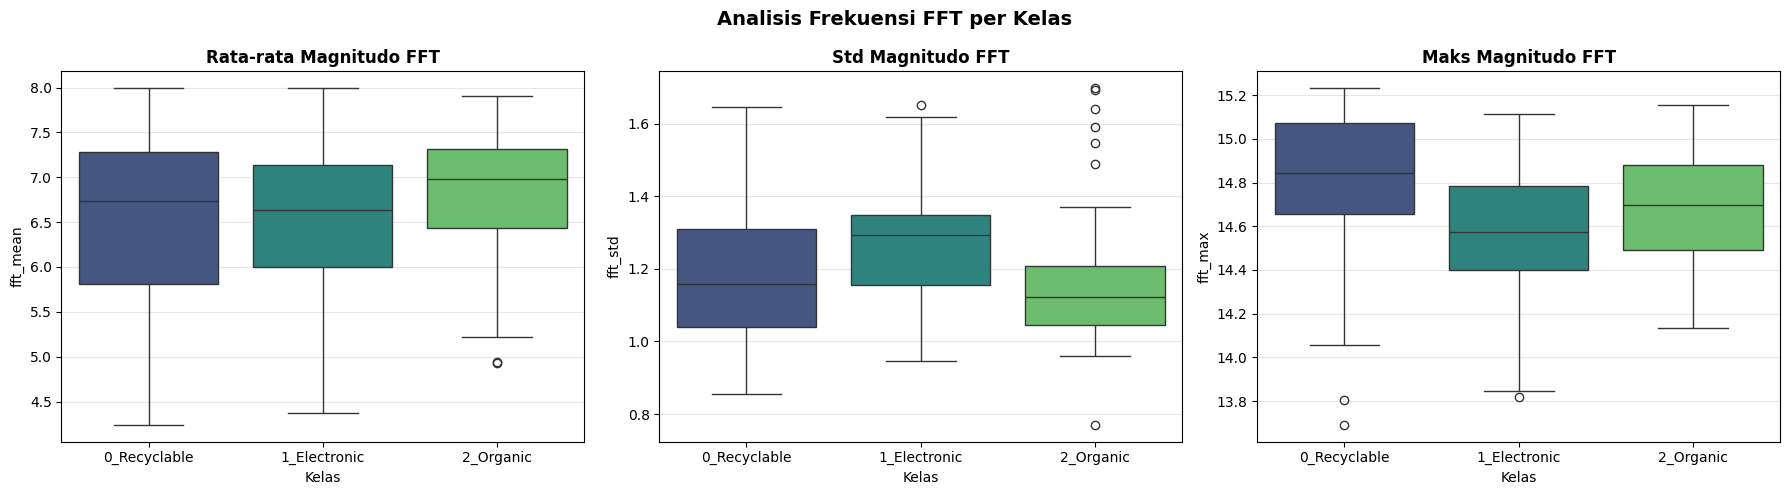

In [19]:
# FFT FREQUENCY ANALYSIS
fft_records = []
sample_per_class = 50
RESIZE_TARGET = (128, 128)

for class_name in os.listdir(TRAIN_DIR):
    class_dir = os.path.join(TRAIN_DIR, class_name)
    files = os.listdir(class_dir)[:sample_per_class]
    
    for img_file in files:
        img_path = os.path.join(class_dir, img_file)
        img = np.array(Image.open(img_path).convert('L').resize(RESIZE_TARGET), dtype=np.float64)
        
        # FFT
        f_transform = np.fft.fft2(img)
        f_shift = np.fft.fftshift(f_transform)
        magnitude = np.log1p(np.abs(f_shift))
        
        fft_records.append({
            "class": class_name,
            "fft_mean": magnitude.mean(),
            "fft_std": magnitude.std(),
            "fft_max": magnitude.max(),
        })

fft_df = pd.DataFrame(fft_records)

# Visualisasi
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = ["fft_mean", "fft_std", "fft_max"]
titles = ["Rata-rata Magnitudo FFT", "Std Magnitudo FFT", "Maks Magnitudo FFT"]

for ax, metric, title in zip(axes, metrics, titles):
    sns.boxplot(data=fft_df, x="class", y=metric, palette="viridis", ax=ax)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Kelas')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Analisis Frekuensi FFT per Kelas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

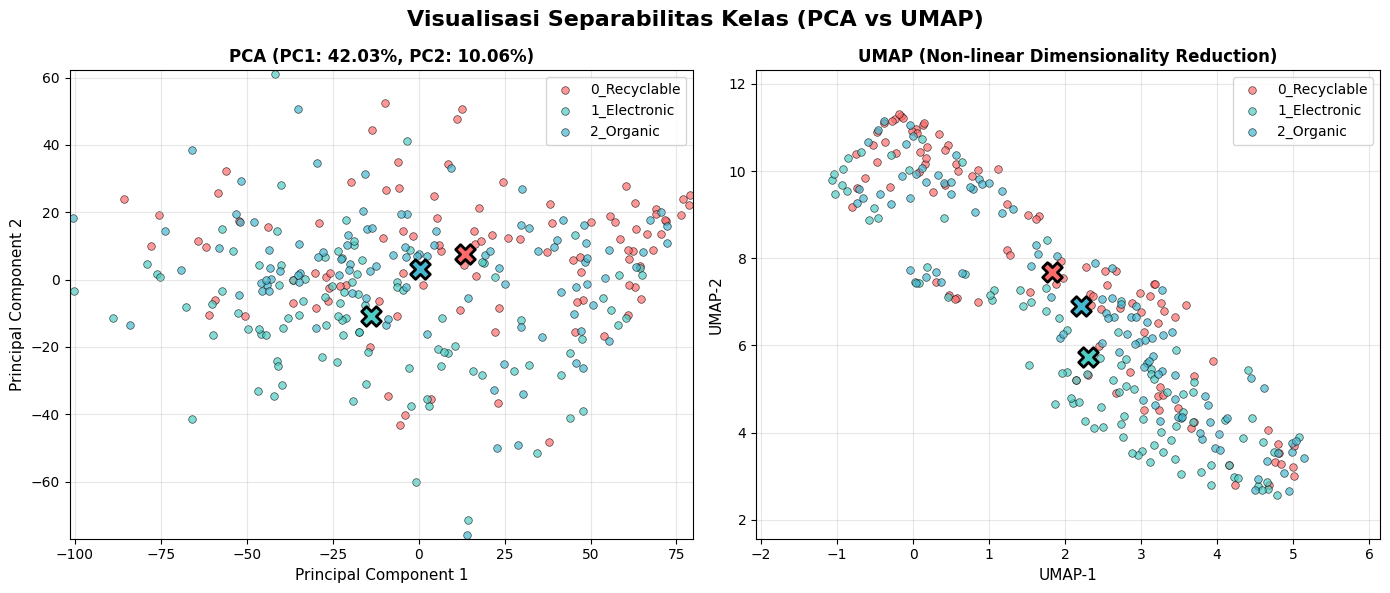

In [20]:
# CLASS SEPARABILITY
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

try:
    import umap
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False
    print("UMAP tidak tersedia — hanya PCA yang akan ditampilkan.")

# Bangun vektor fitur dari citra
feat_size = (64, 64)
feat_vectors = []
feat_labels = []

for class_name in os.listdir(TRAIN_DIR):
    class_dir = os.path.join(TRAIN_DIR, class_name)
    files = os.listdir(class_dir)[:100]  # Batasi untuk efisiensi
    
    for img_file in files:
        img_path = os.path.join(class_dir, img_file)
        img = np.array(Image.open(img_path).convert('L').resize(feat_size), dtype=np.float32).flatten()
        feat_vectors.append(img)
        feat_labels.append(class_name)

X = np.array(feat_vectors)
y = np.array(feat_labels)

# Standarisasi
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Visualisasi dengan fokus terpusat
fig, axes = plt.subplots(1, 2 if HAS_UMAP else 1, figsize=(14, 6))
if not HAS_UMAP:
    axes = [axes]

# Warna untuk setiap kelas
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

# ====== PCA PLOT ======
for i, class_name in enumerate(sorted(set(y))):
    mask = y == class_name
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], 
                    s=30, alpha=0.7, label=class_name, 
                    color=colors[i], edgecolor='black', linewidth=0.5)
    
    # Tambahkan centroid (titik pusat)
    centroid_x = X_pca[mask, 0].mean()
    centroid_y = X_pca[mask, 1].mean()
    axes[0].scatter(centroid_x, centroid_y, s=200, color=colors[i], 
                    edgecolor='black', linewidth=2, marker='X', zorder=5)

axes[0].set_title(f'PCA (PC1: {pca.explained_variance_ratio_[0]:.2%}, PC2: {pca.explained_variance_ratio_[1]:.2%})', 
                  fontweight='bold', fontsize=12)
axes[0].set_xlabel('Principal Component 1', fontsize=11)
axes[0].set_ylabel('Principal Component 2', fontsize=11)
axes[0].legend(loc='best', fontsize=10)
axes[0].grid(alpha=0.3)
axes[0].set_xlim(X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1)
axes[0].set_ylim(X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1)

# ====== UMAP PLOT ======
if HAS_UMAP:
    reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
    X_umap = reducer.fit_transform(X_scaled)
    
    for i, class_name in enumerate(sorted(set(y))):
        mask = y == class_name
        axes[1].scatter(X_umap[mask, 0], X_umap[mask, 1], 
                        s=30, alpha=0.7, label=class_name, 
                        color=colors[i], edgecolor='black', linewidth=0.5)
        
        # Tambahkan centroid
        centroid_x = X_umap[mask, 0].mean()
        centroid_y = X_umap[mask, 1].mean()
        axes[1].scatter(centroid_x, centroid_y, s=200, color=colors[i], 
                        edgecolor='black', linewidth=2, marker='X', zorder=5)
    
    axes[1].set_title('UMAP (Non-linear Dimensionality Reduction)', 
                      fontweight='bold', fontsize=12)
    axes[1].set_xlabel('UMAP-1', fontsize=11)
    axes[1].set_ylabel('UMAP-2', fontsize=11)
    axes[1].legend(loc='best', fontsize=10)
    axes[1].grid(alpha=0.3)
    axes[1].set_xlim(X_umap[:, 0].min() - 1, X_umap[:, 0].max() + 1)
    axes[1].set_ylim(X_umap[:, 1].min() - 1, X_umap[:, 1].max() + 1)

plt.suptitle('Visualisasi Separabilitas Kelas (PCA vs UMAP)', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

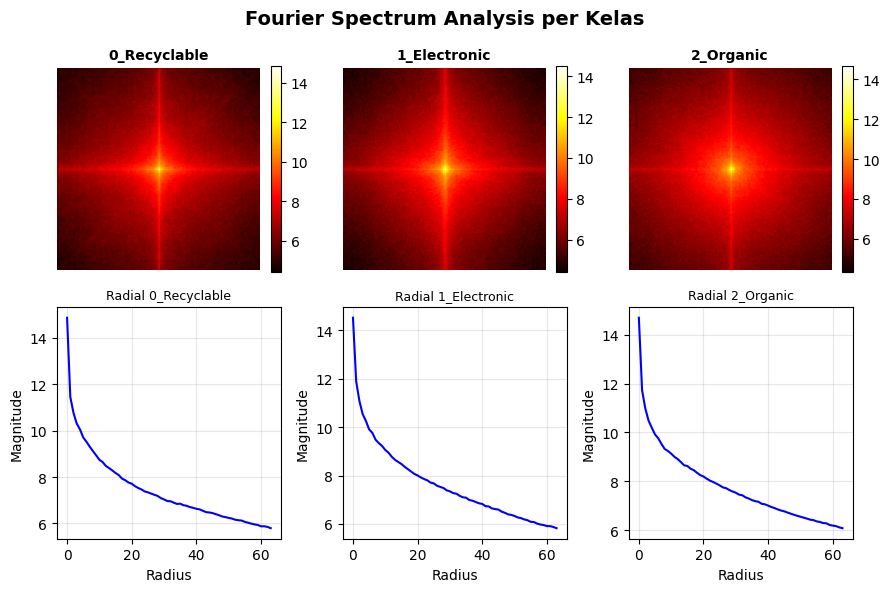

In [21]:
# FOURIER TRANSFORM SPECTRUM
def plot_fourier_spectrum(class_name, num_samples=30, target_size=(128,128)):
    class_dir = os.path.join(TRAIN_DIR, class_name)
    files = os.listdir(class_dir)[:num_samples]
    
    # Accumulate magnitude spectra
    avg_magnitude = None
    
    for img_file in files:
        img_path = os.path.join(class_dir, img_file)
        img = np.array(Image.open(img_path).convert('L').resize(target_size), dtype=np.float64)
        
        # Fourier Transform
        fft = np.fft.fft2(img)
        fft_shift = np.fft.fftshift(fft)
        magnitude = np.log(np.abs(fft_shift) + 1)
        
        if avg_magnitude is None:
            avg_magnitude = magnitude
        else:
            avg_magnitude += magnitude
    
    avg_magnitude /= len(files)
    return avg_magnitude

# Plot Fourier spectrum untuk semua kelas
classes = sorted(os.listdir(TRAIN_DIR))
fig, axes = plt.subplots(2, len(classes), figsize=(len(classes) * 3, 6))

for idx, class_name in enumerate(classes):
    spectrum = plot_fourier_spectrum(class_name)
    
    # Spectrum image
    im = axes[0, idx].imshow(spectrum, cmap='hot')
    axes[0, idx].set_title(f'{class_name}', fontsize=10, fontweight='bold')
    axes[0, idx].axis('off')
    plt.colorbar(im, ax=axes[0, idx], fraction=0.046)
    
    # Radial average
    h, w = spectrum.shape
    y, x = np.ogrid[-h//2:h//2, -w//2:w//2]
    radius = np.sqrt(x**2 + y**2).astype(int)
    
    radial_avg = []
    max_r = min(h, w) // 2
    for r in range(max_r):
        mask = (radius == r)
        if np.any(mask):
            radial_avg.append(np.mean(spectrum[mask]))
    
    # Plot radial average
    axes[1, idx].plot(radial_avg[:100], color='blue', linewidth=1.5)
    axes[1, idx].set_title(f'Radial {class_name}', fontsize=9)
    axes[1, idx].set_xlabel('Radius')
    axes[1, idx].set_ylabel('Magnitude')
    axes[1, idx].grid(alpha=0.3)

plt.suptitle('Fourier Spectrum Analysis per Kelas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

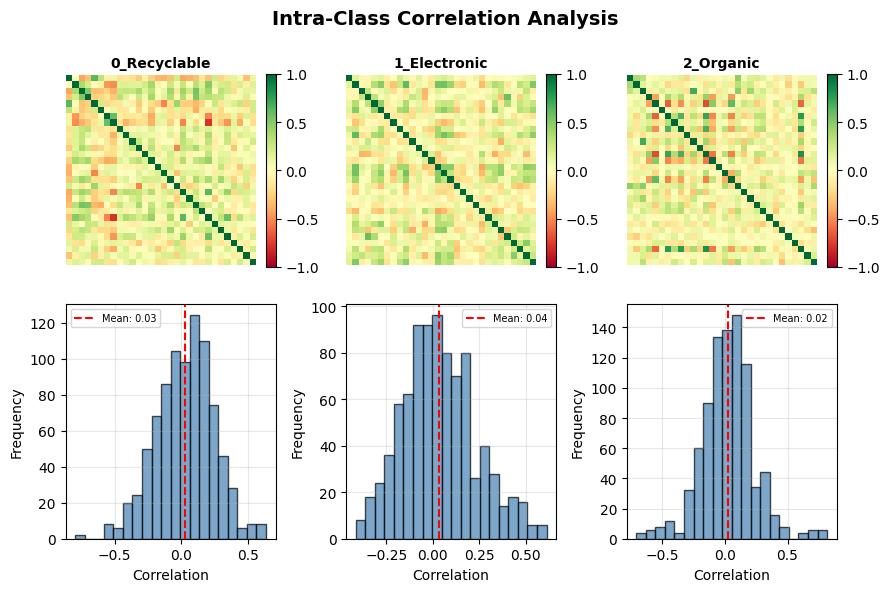

In [22]:
# INTRA CLASS CORELATION
def intra_class_correlation(class_name, num_samples=30):
    class_dir = os.path.join(TRAIN_DIR, class_name)
    files = os.listdir(class_dir)[:num_samples]
    
    images = []
    for img_file in files:
        img_path = os.path.join(class_dir, img_file)
        img = np.array(Image.open(img_path).resize((64, 64)).convert('L')).flatten()
        images.append(img)
    
    images = np.array(images)
    return np.corrcoef(images)

# Plot untuk semua kelas
classes = sorted(os.listdir(TRAIN_DIR))
fig, axes = plt.subplots(2, len(classes), figsize=(len(classes) * 3, 6))

for idx, class_name in enumerate(classes):
    corr_matrix = intra_class_correlation(class_name)
    
    # Correlation matrix
    im = axes[0, idx].imshow(corr_matrix, cmap='RdYlGn', vmin=-1, vmax=1)
    axes[0, idx].set_title(class_name, fontsize=10, fontweight='bold')
    axes[0, idx].axis('off')
    plt.colorbar(im, ax=axes[0, idx], fraction=0.046)
    
    # Distribusi korelasi (tanpa diagonal)
    off_diag = corr_matrix[~np.eye(corr_matrix.shape[0], dtype=bool)]
    axes[1, idx].hist(off_diag, bins=20, color='steelblue', alpha=0.7, edgecolor='black')
    axes[1, idx].axvline(x=np.mean(off_diag), color='red', linestyle='--', 
                        label=f'Mean: {np.mean(off_diag):.2f}')
    axes[1, idx].set_xlabel('Correlation')
    axes[1, idx].set_ylabel('Frequency')
    axes[1, idx].legend(fontsize=7)
    axes[1, idx].grid(alpha=0.3)

plt.suptitle('Intra-Class Correlation Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 5. FEATURE EXTRACTION

In [23]:
class CustomImageDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = []
        self.class_to_idx = {}
        self.samples = []
        
        print("\nScanning dataset...")
        for item in sorted(os.listdir(root_dir)):
            item_path = os.path.join(root_dir, item)
            if os.path.isdir(item_path):
                class_name = item
                class_idx = len(self.classes)
                self.classes.append(class_name)
                self.class_to_idx[class_name] = class_idx
                images = [f for f in os.listdir(item_path) if f.lower().endswith(('.jpg','.jpeg','.png'))]
                print(f"  {class_name}: {len(images)} images (class {class_idx})")
                for img_name in images:
                    self.samples.append((os.path.join(item_path, img_name), class_idx))
        print(f"\nTotal dataset: {len(self.samples)} images")
        self.idx_to_class = {v: k for k, v in self.class_to_idx.items()}
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        try:
            image = Image.open(img_path).convert('RGB')
        except:
            image = Image.new('RGB', (IMG_SIZE, IMG_SIZE), (0,0,0))
        if self.transform:
            image = self.transform(image)
        return image, label

In [24]:
full_dataset = CustomImageDataset(root_dir=TRAIN_DIR, transform=None)
labels_all = [full_dataset[i][1] for i in range(len(full_dataset))]
train_idx, val_idx = train_test_split(
    np.arange(len(full_dataset)),
    test_size=0.12,
    stratify=labels_all,
    random_state=SEED
)

print(f"Train: {len(train_idx):,}")
print(f"Val: {len(val_idx):,}")


Scanning dataset...
  0_Recyclable: 9999 images (class 0)
  1_Electronic: 3961 images (class 1)
  2_Organic: 12567 images (class 2)

Total dataset: 26527 images
Train: 23,343
Val: 3,184


# 6. NORMALISASI/TRANSFORMASI DATA

In [25]:
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

class TransformSubset(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
    
    def __len__(self):
        return len(self.subset)
    
    def __getitem__(self, idx):
        img, label = self.subset[idx]
        if self.transform:
            img = self.transform(img)
        return img, label

In [26]:
train_ds = Subset(full_dataset, train_idx)
val_ds = Subset(full_dataset, val_idx)

train_ds_transformed = TransformSubset(train_ds, train_transform)
val_ds_transformed = TransformSubset(val_ds, val_transform)

# Weighted Sampler untuk handle class imbalance
train_labels = [labels_all[i] for i in train_idx]
class_counts_train = [train_labels.count(c) for c in range(NUM_CLASSES)]
class_weights_sampler = 1.0 / torch.tensor(class_counts_train, dtype=torch.float)
class_weights_sampler = class_weights_sampler / class_weights_sampler.sum() * NUM_CLASSES
class_weights_sampler = class_weights_sampler ** 0.8
sample_weights = [class_weights_sampler[train_labels[i]] for i in range(len(train_ds_transformed))]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_ds_transformed, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=2, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_ds_transformed, batch_size=BATCH_SIZE*2, shuffle=False,
                        num_workers=2, pin_memory=True)

# 7. KONSTRUKSI MODEL

In [27]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
    def forward(self, inputs, targets):
        ce_loss = nn.functional.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = (1 - pt) ** self.gamma * ce_loss
        if self.alpha is not None:
            alpha_t = self.alpha[targets]
            focal_loss = alpha_t * focal_loss
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

def build_convnext_large():
    model = timm.create_model('convnext_large', pretrained=True)
    num_features = model.head.fc.in_features
    model.head.fc = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(num_features, 512),
        nn.ReLU(inplace=True),
        nn.Dropout(0.3),
        nn.Linear(512, NUM_CLASSES)
    )
    for param in model.parameters():
        param.requires_grad = True
    return model


In [28]:
model_tmp = build_convnext_large()
total_params = sum(p.numel() for p in model_tmp.parameters())
print(f'\nConvNeXt-Large | Total params: {total_params:,}')

alpha = torch.tensor([0.3, 0.7, 0.25], dtype=torch.float).to(DEVICE)
criterion = FocalLoss(alpha=alpha, gamma=2.0)
print(f'Focal Loss alpha: {alpha.cpu().numpy()}')

model.safetensors:   0%|          | 0.00/791M [00:00<?, ?B/s]


ConvNeXt-Large | Total params: 197,018,819
Focal Loss alpha: [0.3  0.7  0.25]


# 8. MODEL SELECTION

In [29]:
scaler = GradScaler()

def train_epoch(model, loader, optimizer, accum_steps=GRAD_ACCUM_STEPS):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    optimizer.zero_grad()
    
    for batch_idx, (imgs, lbls) in enumerate(tqdm(loader, desc='  Train', leave=False)):
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        
        with autocast():
            out = model(imgs)
            loss = criterion(out, lbls)
            loss = loss / accum_steps
        
        scaler.scale(loss).backward()
        
        if (batch_idx + 1) % accum_steps == 0 or (batch_idx + 1) == len(loader):
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
        
        total_loss += loss.item() * imgs.size(0) * accum_steps
        correct += out.argmax(1).eq(lbls).sum().item()
        total += imgs.size(0)
    
    return total_loss / total, correct / total

@torch.no_grad()
def validate(model, loader):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for imgs, lbls in tqdm(loader, desc='  Val  ', leave=False):
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        with autocast():
            out = model(imgs)
            loss = criterion(out, lbls)
        total_loss += loss.item() * imgs.size(0)
        preds = out.argmax(1)
        correct += preds.eq(lbls).sum().item()
        total += imgs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(lbls.cpu().numpy())
    f1 = f1_score(all_labels, all_preds, average='macro')
    return total_loss / total, correct / total, f1, all_preds, all_labels

def train_model(model, model_name, train_loader, val_loader):
    backbone_params = []
    classifier_params = []
    for name, param in model.named_parameters():
        if 'head' in name:
            classifier_params.append(param)
        else:
            backbone_params.append(param)
    
    optimizer = optim.AdamW([
        {'params': backbone_params, 'lr': 1e-5},
        {'params': classifier_params, 'lr': 5e-4}
    ], weight_decay=1e-4)
    
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=2, eta_min=1e-7)

    best_f1 = 0
    patience_cnt = 0
    save_path = os.path.join(OUTPUT_DIR, f'best_{model_name}.pth')

    print(f'\n{"─"*55}')
    print(f'  Training: {model_name}')
    print(f'  Backbone LR=1e-5, Classifier LR=5e-4, WD=1e-4')
    print(f'  Epochs={NUM_EPOCHS}, Patience={PATIENCE}')
    print(f'  Loss: Focal Loss (alpha={alpha.cpu().numpy()}, gamma=2.0)')
    print(f'  Augmentation: Flip + Crop + VerticalFlip + Rotation + Jitter')
    print(f'  Gradient Accumulation: {GRAD_ACCUM_STEPS}')
    print(f'  Mixed Precision: Enabled')
    print(f'  Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')
    print(f'{"─"*55}')

    for epoch in range(1, NUM_EPOCHS + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer)
        vl_loss, vl_acc, f1, _, _ = validate(model, val_loader)
        scheduler.step()

        flag = ''
        if f1 > best_f1:
            best_f1 = f1
            patience_cnt = 0
            torch.save(model.state_dict(), save_path)
            flag = ' ✓'
        else:
            patience_cnt += 1

        print(f'  Epoch {epoch:02d}/{NUM_EPOCHS}  '
              f'Train [{tr_loss:.4f} | {tr_acc:.4f}]  '
              f'Val [{vl_loss:.4f} | {vl_acc:.4f} | F1:{f1:.4f}]{flag}')

        if patience_cnt >= PATIENCE:
            print(f'  ⏹ Early stopping pada epoch {epoch}')
            break

    print(f'  Best Val F1: {best_f1:.4f}')
    model.load_state_dict(torch.load(save_path))
    return model

In [30]:
scaler = GradScaler()

model = build_convnext_large().to(DEVICE)
model = train_model(model, 'convnext_large_99', train_loader, val_loader)


───────────────────────────────────────────────────────
  Training: convnext_large_99
  Backbone LR=1e-5, Classifier LR=5e-4, WD=1e-4
  Epochs=35, Patience=10
  Loss: Focal Loss (alpha=[0.3  0.7  0.25], gamma=2.0)
  Augmentation: Flip + Crop + VerticalFlip + Rotation + Jitter
  Gradient Accumulation: 2
  Mixed Precision: Enabled
  Trainable params: 197,018,819
───────────────────────────────────────────────────────


  Epoch 01/35  Train [0.0143 | 0.9554]  Val [0.0074 | 0.9708 | F1:0.9726] ✓


  Epoch 02/35  Train [0.0060 | 0.9782]  Val [0.0070 | 0.9705 | F1:0.9728] ✓


  Epoch 03/35  Train [0.0039 | 0.9841]  Val [0.0064 | 0.9758 | F1:0.9765] ✓


  Epoch 04/35  Train [0.0028 | 0.9886]  Val [0.0050 | 0.9802 | F1:0.9816] ✓


...

  Epoch 21/35  Train [0.0008 | 0.9977]  Val [0.0126 | 0.9802 | F1:0.9810]


  Epoch 22/35  Train [0.0008 | 0.9983]  Val [0.0143 | 0.9793 | F1:0.9816]


  Epoch 23/35  Train [0.0006 | 0.9979]  Val [0.0162 | 0.9771 | F1:0.9782]


  Epoch 24/35  Train [0.0004 | 0.9985]  Val [0.0134 | 0.9808 | F1:0.9832]


  Epoch 25/35  Train [0.0003 | 0.9988]  Val [0.0129 | 0.9808 | F1:0.9832]
  ⏹ Early stopping pada epoch 25
  Best Val F1: 0.9844


# 9. EVALUASI MODEL & VISUALISASI

In [31]:
def evaluate_model(model, model_name, val_loader):
    print(f'\n{"="*50}')
    print(f'Evaluating {model_name} (Validation)')
    print(f'{"="*50}')
    
    _, _, _, y_pred, y_true = validate(model, val_loader)
    
    # Metrik Evaluasi
    f1_macro = f1_score(y_true, y_pred, average='macro')
    f1_per_class = f1_score(y_true, y_pred, average=None)
    accuracy = accuracy_score(y_true, y_pred)
    
    print(f'\n{"="*60}')
    print("METRIK EVALUASI - VALIDATION SET")
    print(f'{"="*60}')
    print(f'Macro F1-Score: {f1_macro:.4f}')
    print(f'Accuracy: {accuracy:.4f}')
    print(f'\nF1-Score per kelas:')
    print(f'  Recyclable (0): {f1_per_class[0]:.4f}')
    print(f'  Electronic (1): {f1_per_class[1]:.4f}')
    print(f'  Organic (2): {f1_per_class[2]:.4f}')
    
    # Classification Report
    print(f'\n{"="*60}')
    print("CLASSIFICATION REPORT")
    print(f'{"="*60}')
    print(classification_report(y_true, y_pred, target_names=['Recyclable', 'Electronic', 'Organic']))
    
    # VISUALISASI 1: Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Recyclable', 'Electronic', 'Organic'],
                yticklabels=['Recyclable', 'Electronic', 'Organic'],
                annot_kws={'size': 14})
    plt.title(f'Confusion Matrix - {model_name} (Validation)', fontsize=16, fontweight='bold')
    plt.xlabel('Predicted', fontsize=12)
    plt.ylabel('Actual', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'confusion_matrix_{model_name}_val.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # VISUALISASI 2: Distribusi Kelas
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Distribusi sebenarnya
    unique, counts = np.unique(y_true, return_counts=True)
    axes[0].bar(['Recyclable', 'Electronic', 'Organic'], counts, color=['#2ecc71', '#3498db', '#e74c3c'])
    axes[0].set_title('Distribusi Kelas - Actual', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Kelas')
    axes[0].set_ylabel('Jumlah Sampel')
    for i, v in enumerate(counts):
        axes[0].text(i, v + 2, str(v), ha='center', fontsize=12, fontweight='bold')
    
    # Distribusi prediksi
    unique_pred, counts_pred = np.unique(y_pred, return_counts=True)
    axes[1].bar(['Recyclable', 'Electronic', 'Organic'], counts_pred, color=['#2ecc71', '#3498db', '#e74c3c'], alpha=0.7)
    axes[1].set_title('Distribusi Kelas - Predicted', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Kelas')
    axes[1].set_ylabel('Jumlah Sampel')
    for i, v in enumerate(counts_pred):
        axes[1].text(i, v + 2, str(v), ha='center', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(f'class_distribution_{model_name}.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # VISUALISASI 3: Per Class F1-Score (Bar Chart)
    plt.figure(figsize=(10, 6))
    classes = ['Recyclable', 'Electronic', 'Organic']
    colors = ['#2ecc71', '#3498db', '#e74c3c']
    bars = plt.bar(classes, f1_per_class, color=colors, edgecolor='black', linewidth=1.5)
    
    # Tambahkan nilai di atas bar
    for bar, value in zip(bars, f1_per_class):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{value:.4f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
    
    plt.ylim(0, 1.05)
    plt.title(f'F1-Score per Kelas - {model_name} (Validation)', fontsize=16, fontweight='bold')
    plt.ylabel('F1-Score', fontsize=12)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'f1_per_class_{model_name}.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # VISUALISASI 4: Confusion Matrix Normalized
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
                xticklabels=['Recyclable', 'Electronic', 'Organic'],
                yticklabels=['Recyclable', 'Electronic', 'Organic'],
                annot_kws={'size': 14})
    plt.title(f'Confusion Matrix (Normalized) - {model_name}', fontsize=16, fontweight='bold')
    plt.xlabel('Predicted', fontsize=12)
    plt.ylabel('Actual', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'confusion_matrix_normalized_{model_name}.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return f1_macro, f1_per_class, y_true, y_pred


Evaluating convnext_large_99 (Validation)



METRIK EVALUASI - VALIDATION SET
Macro F1-Score: 0.9844
Accuracy: 0.9821

F1-Score per kelas:
  Recyclable (0): 0.9764
  Electronic (1): 0.9937
  Organic (2): 0.9830

CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Recyclable       0.97      0.98      0.98      1200
  Electronic       0.99      1.00      0.99       476
     Organic       0.99      0.98      0.98      1508

    accuracy                           0.98      3184
   macro avg       0.98      0.99      0.98      3184
weighted avg       0.98      0.98      0.98      3184



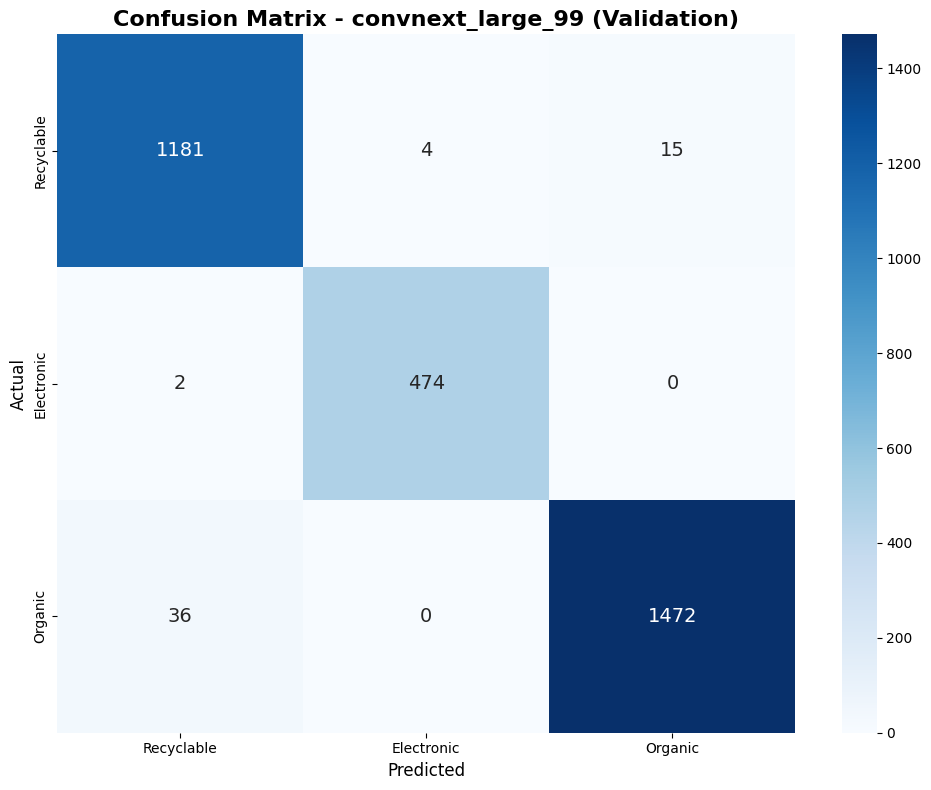

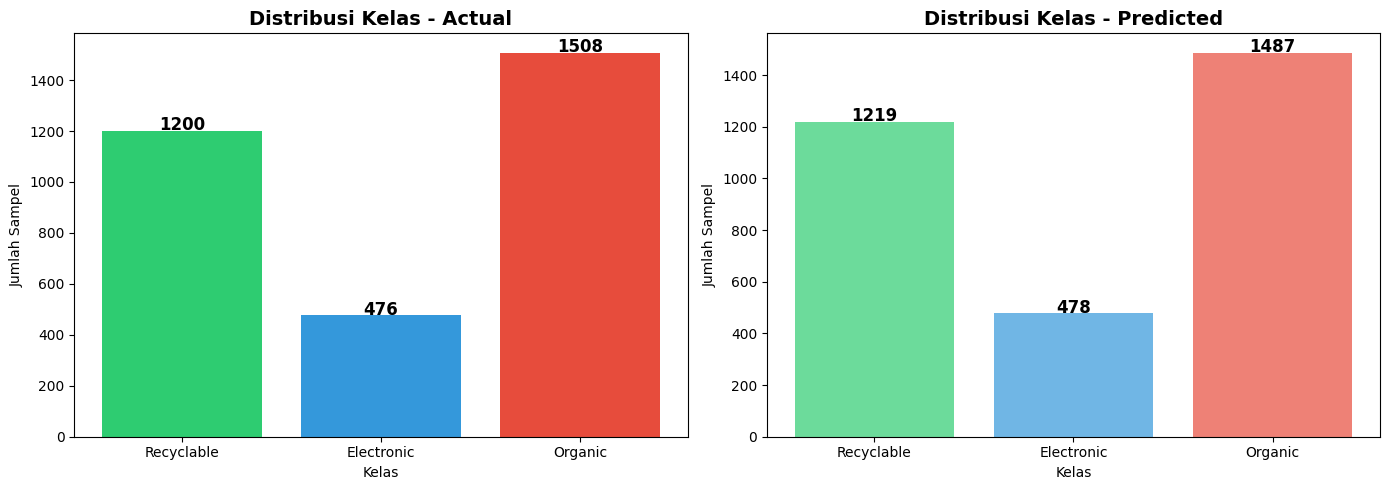

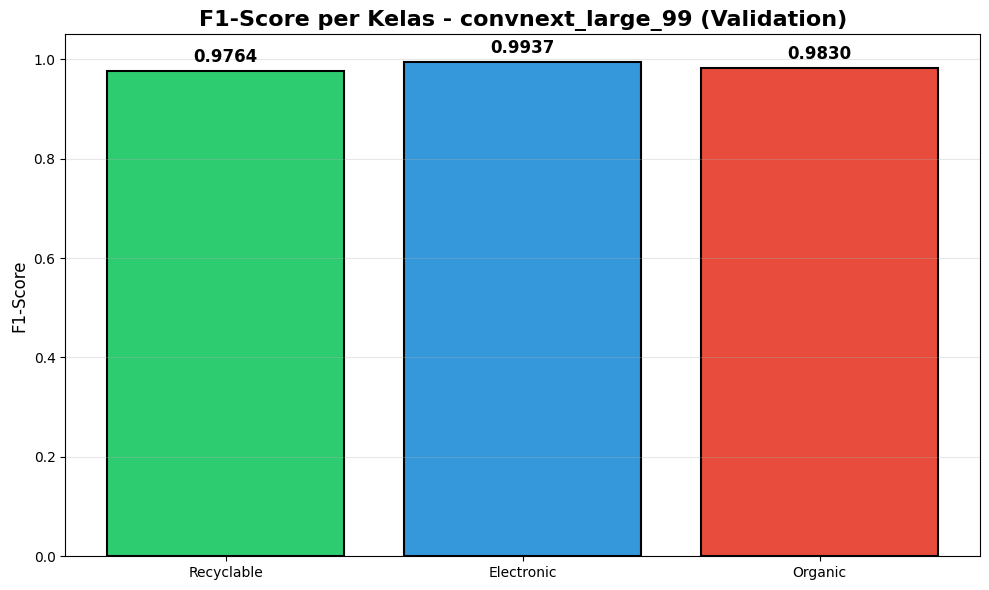

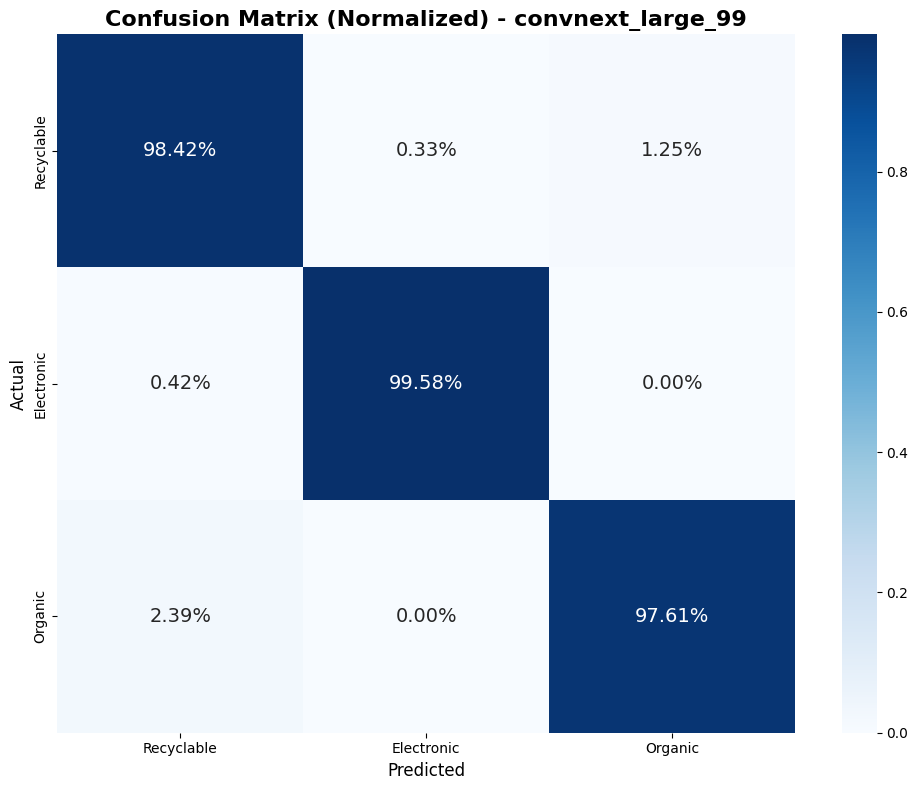

HASIL FASE 1 (INITIAL)
Macro f1-score: 0.9844
f1-score Recyclable: 0.9764
f1-score Electronic: 0.9937
f1-score Organic: 0.9830


In [32]:
f1_val, f1_per_val, y_true, y_pred = evaluate_model(model, 'convnext_large_99', val_loader)

print('HASIL FASE 1 (INITIAL)')
print(f'Macro f1-score: {f1_val:.4f}')
print(f'f1-score Recyclable: {f1_per_val[0]:.4f}')
print(f'f1-score Electronic: {f1_per_val[1]:.4f}')
print(f'f1-score Organic: {f1_per_val[2]:.4f}')

In [33]:
model_path = os.path.join(OUTPUT_DIR, 'best_model.pth')
torch.save(model.state_dict(), model_path)
print(f"Model saved to: {model_path}")

display(FileLink(model_path))

# Tampilkan link download untuk file-file lainnya
print("\nFile yang tersedia untuk di-download:")
for file in os.listdir(OUTPUT_DIR):
    if file.endswith('.pth') or file.endswith('.png') or file.endswith('.csv'):
        file_path = os.path.join(OUTPUT_DIR, file)
        print(f"  - {file}")
        display(FileLink(file_path))

Model saved to: /kaggle/working/best_model.pth


/kaggle/working/best_model.pth


File yang tersedia untuk di-download:
  - best_model.pth


/kaggle/working/best_model.pth

  - f1_per_class_convnext_large_99.png


...

/kaggle/working/confusion_matrix_normalized_convnext_large_99.png

  - best_convnext_large_99.pth


/kaggle/working/best_convnext_large_99.pth

  - confusion_matrix_convnext_large_99_val.png


/kaggle/working/confusion_matrix_convnext_large_99_val.png